In [13]:
# ==============================================================================
# 5.4. PRUEBAS DE VALIDACIÓN: VALIDACIÓN CRUZADA ESTRATIFICADA (K-FOLD, K=5)
# ==============================================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Configuración de la Validación Cruzada Estratificada con 5 Folds (CORREGIDO n_splits)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_cv = []

print("Iniciando Validación Cruzada Estratificada (K=5) sobre la muestra masiva...")

# 2. Bucle iterativo de entrenamiento y validación cruzada
# Usamos X_train (escalado) e y_train para certificar la estabilidad de XGBoost
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Calcular pesos dinámicos específicos para cada partición de entrenamiento
    weights_fold = compute_sample_weight(class_weight='balanced', y=y_tr)
    
    # Clon del modelo campeón con los parámetros optimizados
    model_xgb_cv = XGBClassifier(
        objective='multi:softprob', num_class=3,
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, eval_metric='mlogloss',
        random_state=42, n_jobs=-1
    )
    
    model_xgb_cv.fit(X_tr, y_tr, sample_weight=weights_fold)
    preds_val = model_xgb_cv.predict(X_val)
    
    acc_fold = accuracy_score(y_val, preds_val)
    scores_cv.append(acc_fold)
    print(f" -> Iteración (Fold) {fold} completada. Exactitud (Accuracy): {acc_fold:.4f}")

# 3. Consolidación de estadísticos de estabilidad
mean_cv = np.mean(scores_cv)
std_cv = np.std(scores_cv)

print(f"\n=======================================================")
print(f" RESULTADO GLOBAL DE LA VALIDACIÓN CRUZADA")
print(f"=======================================================")
print(f"Exactitud Promedio (Mean Accuracy): {mean_cv:.4f}")
print(f"Desviación Estándar (Std Deviation):  {std_cv:.4f}")

Iniciando Validación Cruzada Estratificada (K=5) sobre la muestra masiva...
 -> Iteración (Fold) 1 completada. Exactitud (Accuracy): 0.6494
 -> Iteración (Fold) 2 completada. Exactitud (Accuracy): 0.6442
 -> Iteración (Fold) 3 completada. Exactitud (Accuracy): 0.6463
 -> Iteración (Fold) 4 completada. Exactitud (Accuracy): 0.6460
 -> Iteración (Fold) 5 completada. Exactitud (Accuracy): 0.6453

 RESULTADO GLOBAL DE LA VALIDACIÓN CRUZADA
Exactitud Promedio (Mean Accuracy): 0.6462
Desviación Estándar (Std Deviation):  0.0017


In [10]:
# ==============================================================================
# 1. DIVISIÓN ESTRATIFICADA Y ESTANDARIZACIÓN (PETICIÓN TUTORA)
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler  # <--- NUEVO: Para normalizar
import numpy as np

# Carga de la base (Ajusta la ruta si es necesario)
df = pd.read_csv("base_diabetes.csv")
X = df.drop(columns=['Diabetes_012'])
y = df['Diabetes_012'].astype(int)

# División 80/20 Estratificada (Cambiado test_split por test_size)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Aplicamos la Estandarización para la Red Neuronal y Regresión Logística
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw) # Se ajusta SOLO con Train
X_test = scaler.transform(X_test_raw)       # Se transforma Test pasivamente

# Cálculo de pesos inversos para mitigar el severo desbalanceo de clases
from sklearn.utils.class_weight import compute_sample_weight
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)


# ==============================================================================
# 2. DEFINICIÓN DE MODELOS CON TUNING DE HIPERPARÁMETROS
# ==============================================================================
# Regresión Logística Multinomial (Línea Base Ponderada)
model_lr = LogisticRegression(
    multi_class='multinomial', solver='lbfgs', max_iter=1000,
    class_weight='balanced', random_state=42
)

# XGBoost Multiclase (Modelo Campeón - Hiperparámetros Ajustados a Mano)
model_xgb = XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=300, max_depth=6, learning_rate=0.05, # <--- TUNING
    subsample=0.8, colsample_bytree=0.8, eval_metric='mlogloss',
    random_state=42, n_jobs=-1
)

# Perceptrón Multicapa (Red Neuronal MLP - Grupo de Control Estándar)
model_mlp_standard = MLPClassifier(
    hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
    batch_size=128, max_iter=300, early_stopping=True, # <--- TUNING
    random_state=42
)


# ==============================================================================
# 3. ENTRENAMIENTO Y EVALUACIÓN CLÍNICA DIVERSIFICADA
# ==============================================================================
from sklearn.metrics import classification_report, cohen_kappa_score

# Ajustar y predecir Regresión Logística
model_lr.fit(X_train, y_train)
preds_lr = model_lr.predict(X_test)

# Ajustar y predecir XGBoost (Inyectando la matriz de pesos por fila)
model_xgb.fit(X_train, y_train, sample_weight=sample_weights_train)
preds_xgb = model_xgb.predict(X_test)

# Ajustar y predecir Red Neuronal MLP
model_mlp_standard.fit(X_train, y_train)
preds_mlp_std = model_mlp_standard.predict(X_test)

# Función para imprimir los reportes limpios (Sin warnings en pantalla)
def evaluar_modelo_clinico(nombre, y_real, y_pred):
    print(f"\n=======================================================")
    print(f" EVALUACIÓN CLÍNICA DIVERSIFICADA: {nombre}")
    print(f"=======================================================")
    print(classification_report(y_real, y_pred, digits=4, 
                                target_names=['0: Sano', '1: Prediabetes', '2: Diabetes'], 
                                zero_division=0)) # <--- Limpea los warnings
    kappa = cohen_kappa_score(y_real, y_pred)
    print(f"Índice Kappa de Cohen (Corrección por azar): {kappa:.4f}")

evaluar_modelo_clinico("REGRESIÓN LOGÍSTICA (LÍNEA BASE)", y_test, preds_lr)
evaluar_modelo_clinico("XGBOOST MULTICLASE (CAMPEÓN)", y_test, preds_xgb)
evaluar_modelo_clinico("PERCEPTRÓN MULTICAPA (MLP ESTÁNDAR)", y_test, preds_mlp_std)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



 EVALUACIÓN CLÍNICA DIVERSIFICADA: REGRESIÓN LOGÍSTICA (LÍNEA BASE)
                precision    recall  f1-score   support

       0: Sano     0.9510    0.6630    0.7813     42741
1: Prediabetes     0.0326    0.3261    0.0593       926
   2: Diabetes     0.3533    0.5834    0.4401      7069

      accuracy                         0.6458     50736
     macro avg     0.4456    0.5242    0.4269     50736
  weighted avg     0.8510    0.6458    0.7206     50736

Índice Kappa de Cohen (Corrección por azar): 0.2461

 EVALUACIÓN CLÍNICA DIVERSIFICADA: XGBOOST MULTICLASE (CAMPEÓN)
                precision    recall  f1-score   support

       0: Sano     0.9532    0.6508    0.7735     42741
1: Prediabetes     0.0297    0.2646    0.0534       926
   2: Diabetes     0.3402    0.6403    0.4443      7069

      accuracy                         0.6423     50736
     macro avg     0.4410    0.5185    0.4237     50736
  weighted avg     0.8510    0.6423    0.7145     50736

Índice Kappa de Cohen (C

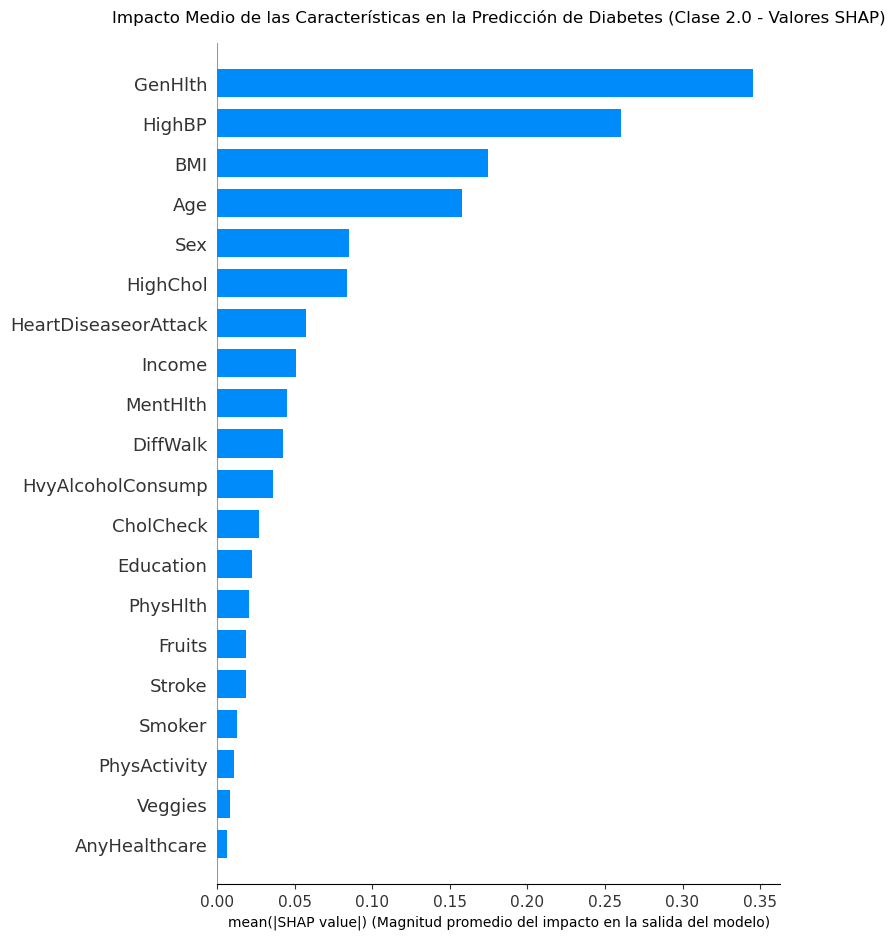

In [11]:
# ==============================================================================
# 5.5. MÓDULO DE INTELIGENCIA ARTIFICIAL EXPLICABLE (XAI) - VALORES SHAP
# ==============================================================================
import shap
import matplotlib.pyplot as plt

# 1. Extracción de una muestra de control aleatoria y representativa (Petición de Mariana)
# Se toman 1,000 registros del conjunto de entrenamiento estandarizado para optimizar el cómputo
X_sample = shap.sample(X_train, 1000, random_state=42)

# 2. Inicialización del explicador nativo para árboles (TreeExplainer) con XGBoost
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_sample)

# 3. Renderización y guardado del gráfico Summary Plot para la Clase 2.0 (Diabetes)
# Nota: Ajustamos el tamaño a formato Word (13 cm de ancho aprox.)
plt.figure(figsize=(10, 6))

# Extraemos los nombres de las columnas desde el dataframe original
features_names = X.columns.tolist()

# Graficamos el impacto medio absoluto para la Clase 2.0 (Diabetes)
# Dependiendo de la versión de xgboost, shap_values puede ser una lista (un elemento por clase)
# Si es una lista, indexamos [2] para la clase de Diabetes diagnosticada
if isinstance(shap_values, list):
    shap_val_clase = shap_values[2]
else:
    # Para versiones donde retorna un array tridimensional (muestras, variables, clases)
    shap_val_clase = shap_values[:, :, 2] if len(shap_values.shape) == 3 else shap_values

shap.summary_plot(
    shap_val_clase, 
    X_sample, 
    feature_names=features_names, 
    plot_type="bar", 
    show=False
)

plt.title('Impacto Medio de las Características en la Predicción de Diabetes (Clase 2.0 - Valores SHAP)', fontsize=12, pad=15)
plt.xlabel('mean(|SHAP value|) (Magnitud promedio del impacto en la salida del modelo)', fontsize=10)
plt.tight_layout()

# Guardar la imagen en alta resolución para insertarla directamente en Word
plt.savefig('grafico_shap_clase2.png', dpi=300, bbox_inches='tight')
plt.show()

DASHBOARD

In [19]:
# ==============================================================================
# ENRIQUECIMIENTO DEL DATASET PARA POWER BI (DATOS 100% REALES DEL CDC)
# ==============================================================================

import pandas as pd
import numpy as np

print("Preparando la matriz de características original (X)...")

# 1. Separamos la variable objetivo (Diabetes_012) de las explicativas (X)
X_completo = df.drop(columns=['Diabetes_012'])

print("Generando predicciones y probabilidades con tu modelo campeón XGBoost...")

# 2. Obtenemos las predicciones y probabilidades directamente sobre la matriz X real
preds_totales = model_xgb.predict(X_completo)
probabilidades = model_xgb.predict_proba(X_completo)

# 3. Clonamos el dataframe original para no corromper la fuente
df_bi = df.copy()

# 4. Inyectamos los resultados predictivos calculados por el modelo
df_bi['Prediccion_Diabetes'] = preds_totales
df_bi['Prob_Sano'] = probabilidades[:, 0]
df_bi['Prob_Prediabetes'] = probabilidades[:, 1]
df_bi['Prob_Diabetes'] = probabilidades[:, 2]

# 5. Exportamos el dataset enriquecido final a un archivo plano seguro
df_bi.to_csv("base_diabetes_predictivo.csv", index=False)

print("\n=======================================================")
print(" ¡ÉXITO ")
print("=======================================================")
print("Se ha generado el archivo: 'base_diabetes_predictivo.csv'")
print("Este archivo contiene los datos puros y reales del CDC junto a la IA.")

Preparando la matriz de características original (X)...
Generando predicciones y probabilidades con tu modelo campeón XGBoost...

 ¡ÉXITO 
Se ha generado el archivo: 'base_diabetes_predictivo.csv'
Este archivo contiene los datos puros y reales del CDC junto a la IA.
